# Análise Exploratória dos Dados - parte 1

> **Autor**: Miguel Vieira Machado Pim  
> **Contexto**: Desafio do processo seletivo de estágio IndustriALL

Notebooks anteriores a este:

1. [`01_pre_processing`](01_pre_processing.ipynb)
2. [`02_data_visualization`](02_data_visualization.ipynb)

Este notebook visa analisar valores que estão faltando no dataset, ou seja, datas que não estão no dataset e valores nulos de sensores.

## Bibliotecas

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

## Funções

In [2]:
def preprocess_data(data_path: Path) -> pd.DataFrame:
    """
    Essa função coleta todos os 53 arquivos csv e converte eles em um único dataframe final.

    Args:
        data_path (Path): Caminho para a pasta que contém os arquivos csv.

    Returns:
        pd.DataFrame: Dataframe final contendo todas as features e a coluna target.
    """
    # Coletando todos os arquivos
    feature_dfs = []
    target_df = None

    for file in data_path.glob("*.csv"):
        if "target" in file.name:
            target_df = pd.read_csv(file)
            target_df.columns = ["timestamp", "target"]
        else:
            sensor_id = int(re.search(r"\d+", file.stem).group())
            
            df = pd.read_csv(file)
            df.columns = ["timestamp", f"sensor_{sensor_id}"]

            feature_dfs.append(df)
    
    feature_dfs.sort(
        key=lambda df: int(df.columns[1].split("_")[1])
    )
    
    # Tratando tipos dos datasets
    for df in feature_dfs:
        df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    target_df["target"] = target_df["target"].map({
        "NORMAL": 0,
        "ANORMAL": 1
    }).astype(int)
    target_df["timestamp"] = pd.to_datetime(target_df["timestamp"])
    
    # Construindo dataset final
    df_final = (
        pd.concat(
            [target_df.set_index("timestamp")] +
            [df.set_index("timestamp") for df in feature_dfs],
            axis=1,
            join="outer" # Para mantermos timestamps que não estão em todas as tabelas
        )
        .sort_index()
    )
    
    return df_final

In [3]:
def plotar_nulos_no_tempo(df, variaveis, figsize=(18, 2.5)):
    dados = df.sort_index()
    target = dados["target"]

    inicios_falha = dados.index[
        target.eq(1) & target.shift(fill_value=0).eq(0)
    ]

    finais_falha = dados.index[
        target.eq(1) & target.shift(-1, fill_value=0).eq(0)
    ]

    fig, axes = plt.subplots(
        len(variaveis),
        1,
        figsize=(figsize[0], figsize[1] * len(variaveis)),
        sharex=True
    )

    axes = [axes] if len(variaveis) == 1 else axes

    for i, (ax, variavel) in enumerate(zip(axes, variaveis)):
        nulos = dados[variavel].isna()

        ax.fill_between(
            dados.index,
            0,
            1,
            where=nulos,
            step="post",
            alpha=0.9
        )

        for inicio in inicios_falha:
            ax.axvline(
                inicio,
                color="red",
                linestyle="--",
                linewidth=1,
                label="Início da falha" if i == 0 and inicio == inicios_falha[0] else None
            )

        for fim in finais_falha:
            ax.axvline(
                fim,
                color="black",
                linestyle=":",
                linewidth=1,
                label="Fim da falha" if i == 0 and fim == finais_falha[0] else None
            )

        ax.set_yticks([0, 1])
        ax.set_yticklabels(["PRESENTE", "NULO"])
        ax.set_ylim(-0.05, 1.05)

        ax.set_title(
            f"{variavel} — {nulos.sum():,} nulos ({nulos.mean():.2%})"
        )

    axes[0].legend(loc="upper right")
    axes[-1].set_xlabel("Timestamp")

    fig.suptitle("Valores nulos e falhas ao longo do tempo", y=1)
    plt.tight_layout()
    plt.show()

## Carregando os dados

In [4]:
data_path = Path("../data")

industry_df = preprocess_data(data_path)

In [5]:
eda_df = industry_df.copy()
eda_df

,target,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,0,4.548754,90.886874,58.698896,89.301134,1011.733181,97.284889,33.248746,-10.390227,29.262578,...,101.547023,154.291476,114.466107,103.082616,119.246973,60.729332,310.022461,124.735196,426.651658,410.820484
2018-04-01 00:01:00,0,7.887998,56.555373,80.802810,120.898222,1358.466600,202.583688,32.494870,19.427739,61.038519,...,71.846296,59.239207,90.076161,93.760055,63.457947,62.910653,306.084796,158.822485,375.316113,143.620728
2018-04-01 00:02:00,0,4.975919,182.086958,87.273632,9.914782,1056.489015,147.098428,36.402837,38.900027,30.304666,...,59.174616,87.136301,99.274584,111.916792,60.560834,81.332910,353.863854,88.772027,444.809188,618.898000
2018-04-01 00:03:00,0,6.304142,58.417235,75.059520,64.167463,1619.924847,307.722320,34.283344,46.602862,44.859311,...,0.674927,110.321579,103.978381,103.705604,24.141894,36.219671,301.563110,53.387484,414.052496,427.323378
2018-04-01 00:04:00,0,1.671733,108.946809,94.910470,14.551922,591.648283,-7.684779,30.980682,39.293311,1.229287,...,71.785623,112.435498,103.170425,110.566095,53.913605,116.770552,298.957820,168.746952,431.548430,514.659884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-31 23:55:00,0,6.066461,128.157145,144.452803,66.621842,1791.181163,172.833101,13.116142,52.438915,32.694638,...,77.001917,105.953758,169.203415,74.959180,159.206995,98.736928,432.326663,199.902569,NaN,343.198701
2018-08-31 23:56:00,0,4.057784,-31.186502,49.775117,69.397205,1166.424000,146.161645,26.785100,17.436183,39.612008,...,32.268873,12.201309,59.127149,149.304241,26.936970,125.800942,402.294815,218.904951,NaN,381.082811
2018-08-31 23:57:00,0,6.751912,80.433446,107.038506,137.923928,1060.918628,106.901675,37.495990,20.406074,33.073722,...,87.497962,90.664739,144.615688,29.140853,118.974814,75.747273,269.339456,260.899365,NaN,452.482461


## Analisando datas que não estão no dataset

In [6]:
timestamps = pd.DatetimeIndex(eda_df.index).sort_values().unique()

datas_esperadas = pd.date_range(
    start=timestamps.min(),
    end=timestamps.max(),
    freq="1min"
)

datas_ausentes = datas_esperadas.difference(timestamps)

print(f"Período: {timestamps.min()} até {timestamps.max()}")
print(f"Datas esperadas: {len(datas_esperadas):,}")
print(f"Datas existentes: {len(timestamps):,}")
print(f"Datas ausentes: {len(datas_ausentes):,}")
print(f"Cobertura: {len(timestamps) / len(datas_esperadas):.2%}")

Período: 2018-04-01 00:00:00 até 2018-08-31 23:59:00
Datas esperadas: 220,320
Datas existentes: 220,320
Datas ausentes: 0
Cobertura: 100.00%


Todas as datas possíveis para a frequência de 1 minuto existem no *dataset*. Portanto, não devemos nos preocupar em tratá-las.

## Analisando valores nulos no dataset

In [7]:
nulos = pd.DataFrame({
    "quantidade_nulos": eda_df.isna().sum(),
    "percentual_nulos": eda_df.isna().mean().mul(100).round(2)
}).sort_values("quantidade_nulos", ascending=False)

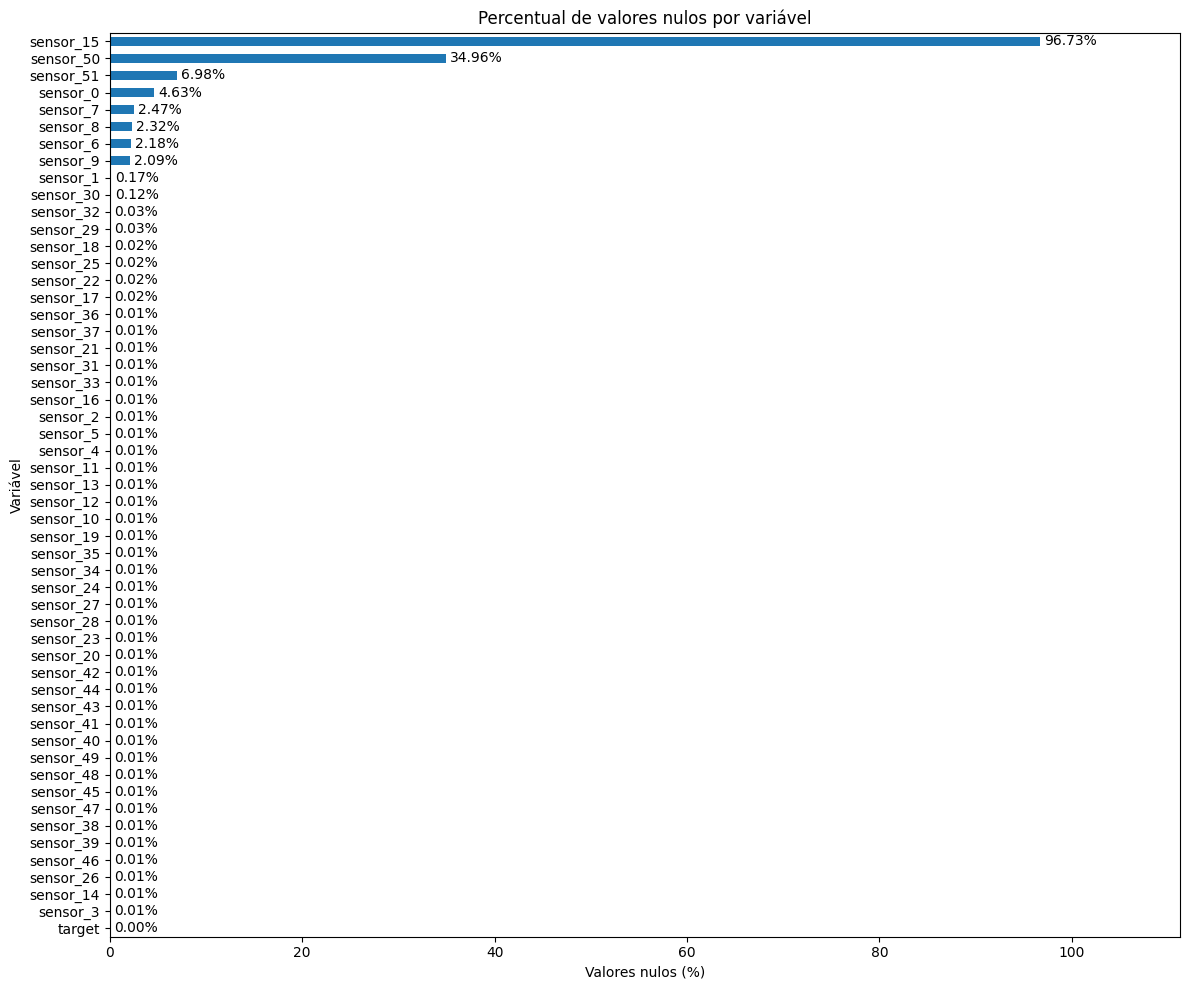

In [8]:
percentuais = nulos["percentual_nulos"].sort_values()

fig, ax = plt.subplots(figsize=(12, 10))

percentuais.plot.barh(ax=ax)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{valor:.2f}%" for valor in percentuais],
        padding=3
    )

ax.set_xlabel("Valores nulos (%)")
ax.set_ylabel("Variável")
ax.set_title("Percentual de valores nulos por variável")

ax.set_xlim(0, percentuais.max() * 1.15)

plt.tight_layout()
plt.show()

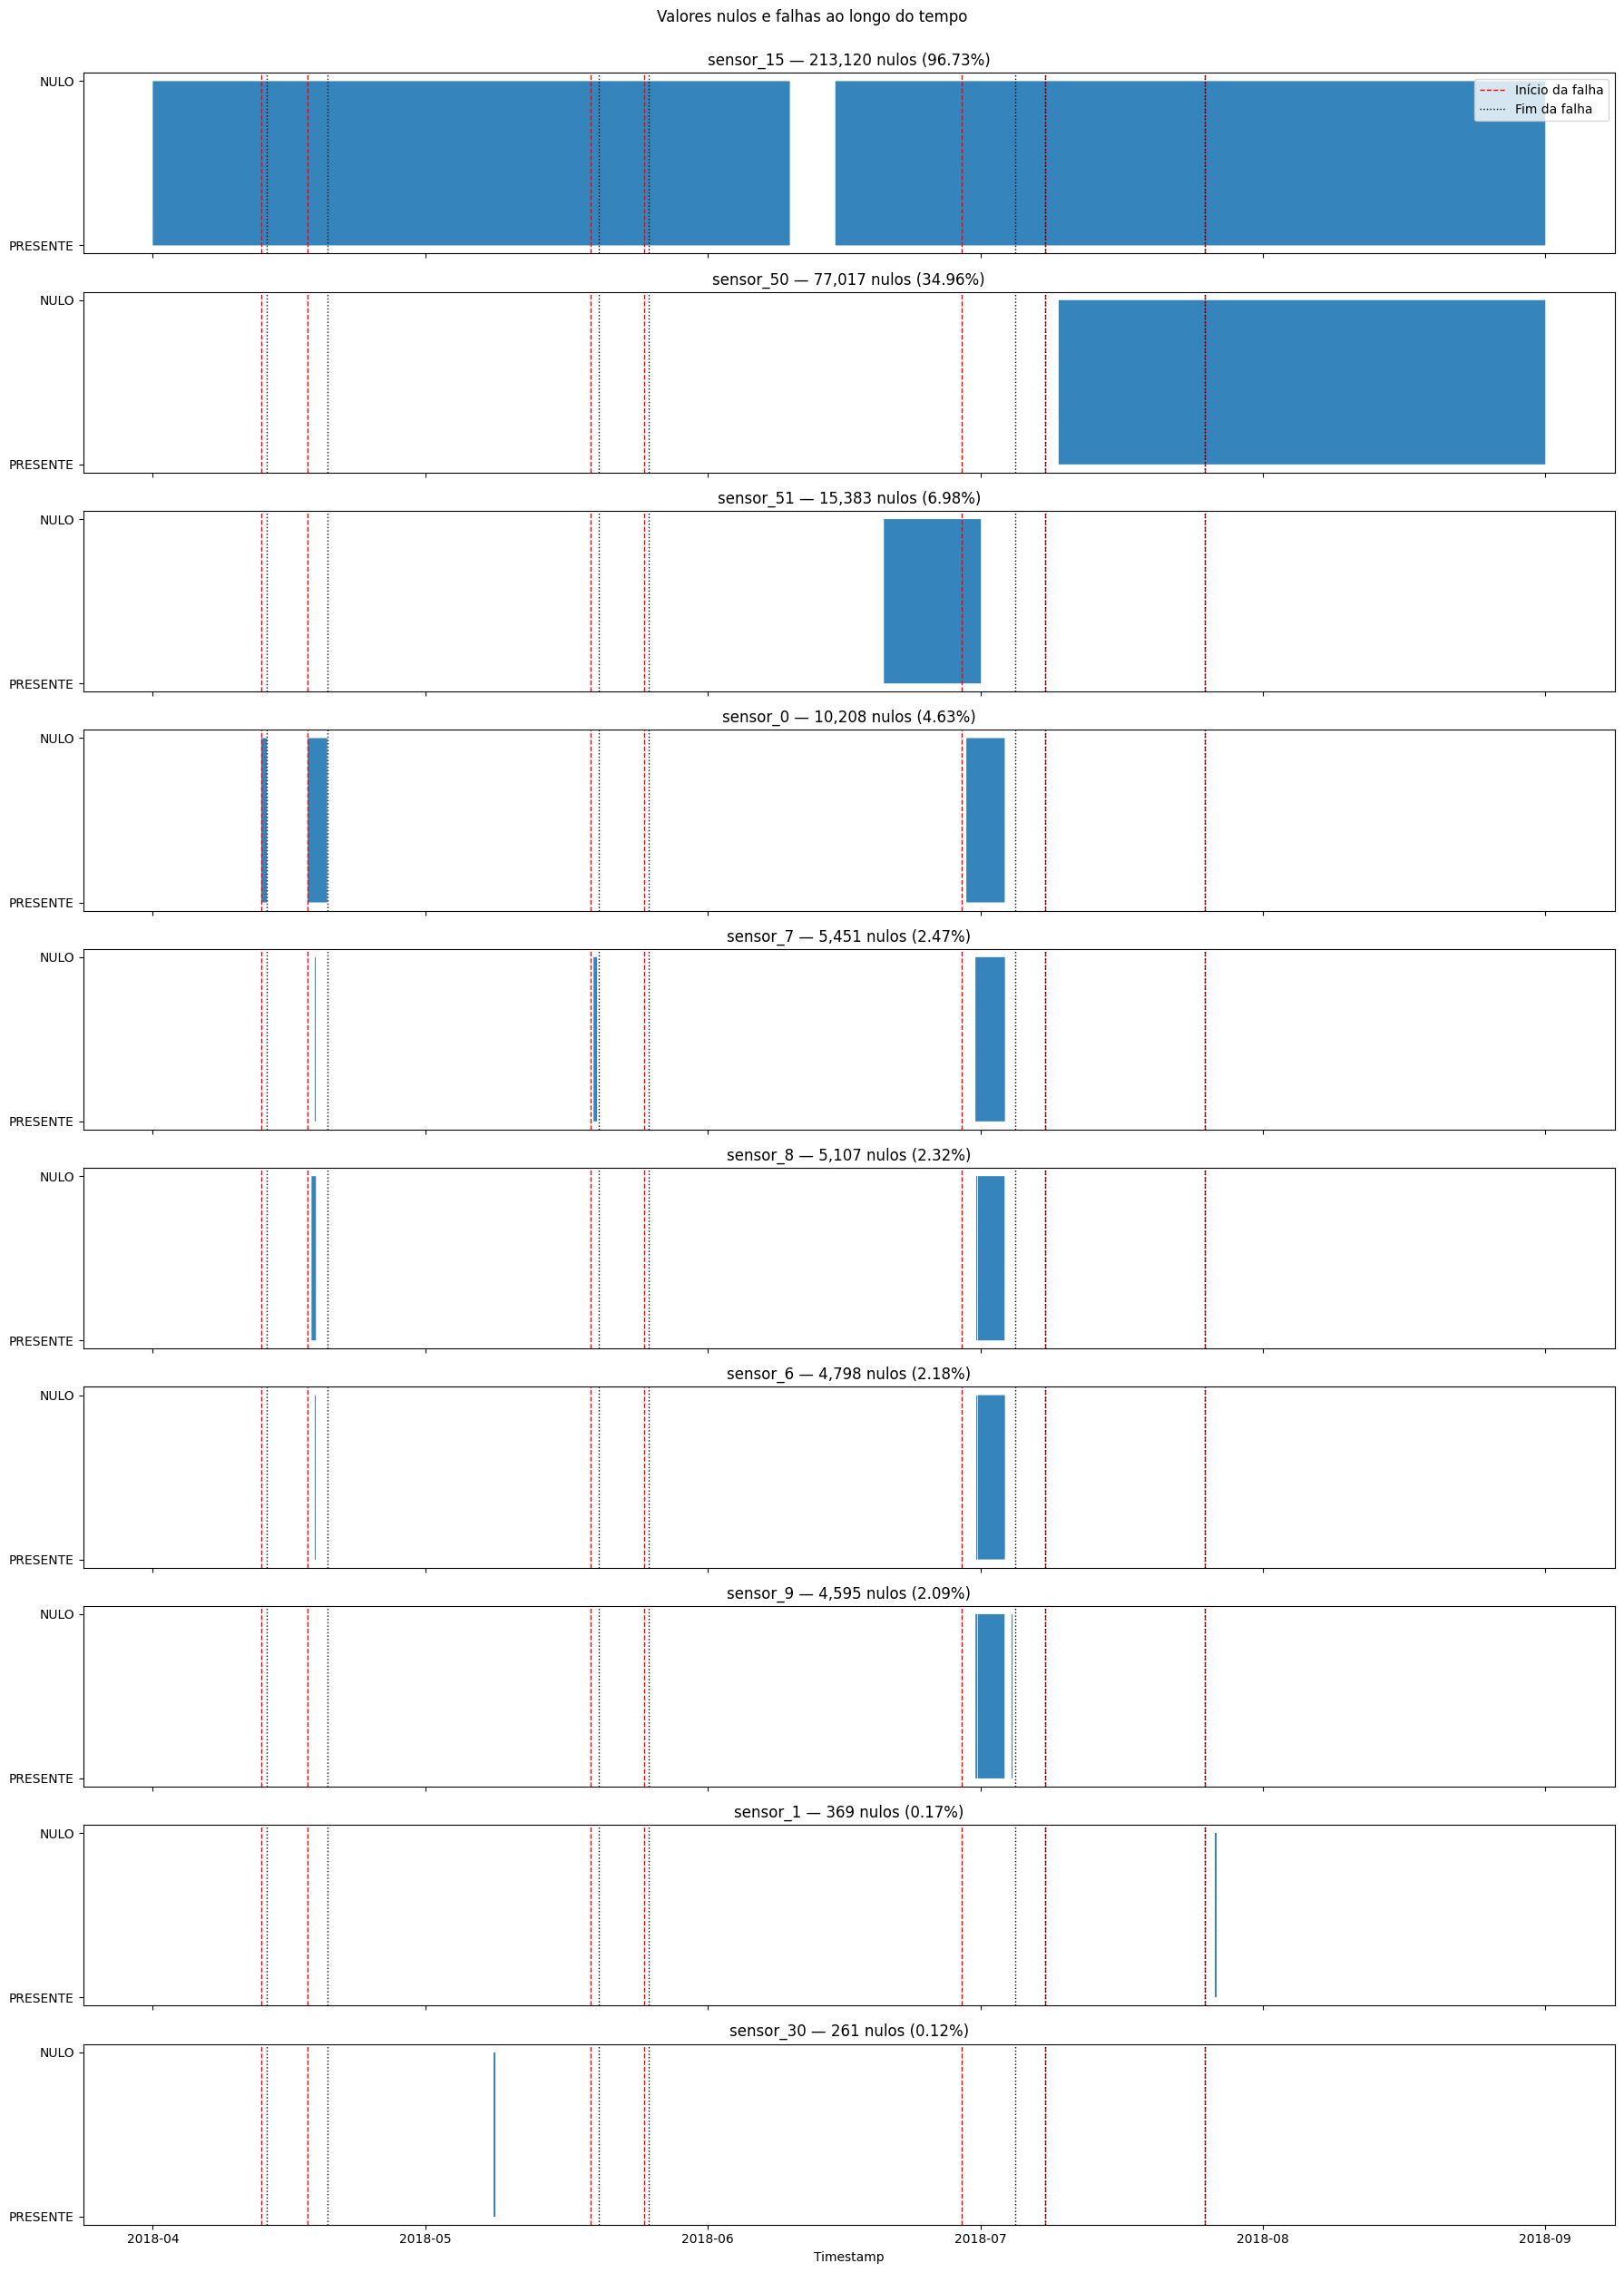

In [9]:
plotar_nulos_no_tempo(
    eda_df,
    variaveis=nulos.index[:10].tolist()
)

A partir dessa visualização é possível analisar alguns pontos importantes:

- O `sensor_15` parece explicar muito bem a anomalia que visualizamos no notebook anterior.
- O `sensor_51` parece explicar de alguma forma a falha **5**, pois ele fica nulo antes da falha acontecer e volta a medir valores antes da falha acontecer.
- O `sensor_0` parece ter uma ligação com as falhas **1**, **2** e **5**, uma vez que apresentar valores nulos exatamente no período da falha.
- O `sensor_6`, `sensor_7`, `sensor_8` e `sensor_9` parecem ter relação com algumas das falhas também por apresentarem valores nulos dentro do período de falha.

## Conclusão

Os valores nulos de alguns sensores parecem explicar bem algumas das falhas que acontecem nos equipamentos e, portanto, serão variáveis importantes para a modelagem do nosso problema. Outros sensores não nos apontam características suficientes para dizermos isso por apresentarem poucos valores nulos.

A estratégia que utilizaremos será:

- Modelar os sensores que possuem relação com a falha, para o nosso modelo aprender com essa informação também.
  - `sensor_51`, `sensor_0`, `sensor_6`, `sensor_7`, `sensor_8`, `sensor_9`.
- Interpolar os demais sensores que não apresentaram informações suficientes de ligação com as falhas.